0 %d s
1 %.3g s
2 %.3g
3 %.3g
4 %.3g
5 %.3g  Tm/s^2


/home/fran/Projects/Python_projects/artemis/main_mpl.py:143: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = FuncAnimation(fig, animate, interval=30)


24360


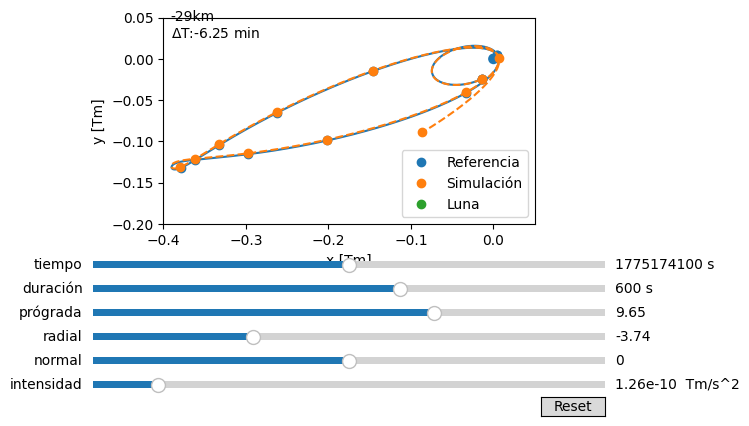

None


In [1]:
%load_ext autoreload
%autoreload 2
from main import *

In [82]:
time_range, horizon_data = interpolate_horizon_data(DATOS, PROGRESS)
time_out, sim = run_simulation(
    time_range,
    horizon_data,
    burns=[
        (p0[0],
        p0[1],
        B @ np.array(p0[2:5]),
        p0[5]),
    ]
)
time_out = time_out.astype("datetime64[s]")

In [81]:
usar = sim # o `horizon_data` si queres ver la real para todas estas

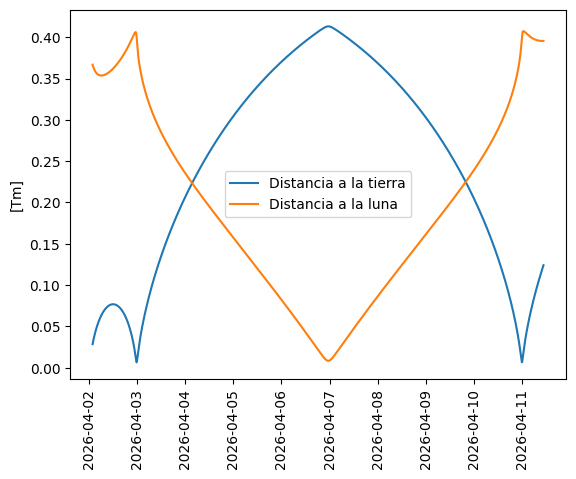

In [50]:
plt.xticks(rotation='vertical')
plt.plot(time_out,np.linalg.norm(usar[:,0:3,1],axis=1), label="Distancia a la tierra")
plt.plot(time_out,np.linalg.norm(usar[:,0:3,2],axis=1), label="Distancia a la luna")
plt.ylabel("[Tm]")
plt.legend()

[-1.40555828e-11 -1.40291738e-11 -1.40028957e-11 ... -3.21740665e-12 -3.21659401e-12 -3.21578191e-12]


Text(0, 0.5, 'Energía por unidad de massa [(Tm/s)^2]')

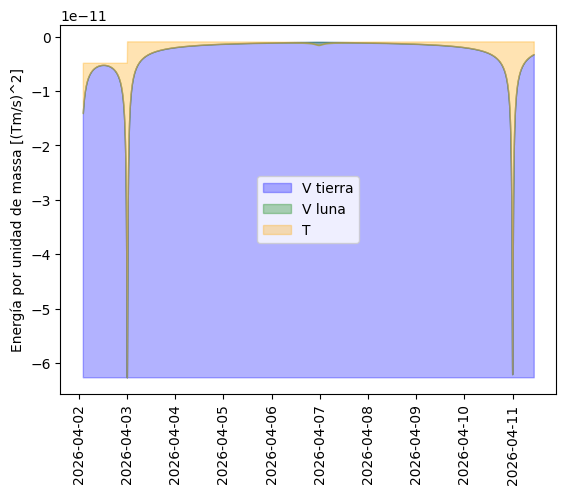

In [51]:
# Solo tiene en cuenta el sistema Tierra-Luna
# Noten como se puede ver el aumento de energía con el primer impulso

T = 0.5 * np.sum(usar[:,3:6,1]**2,axis=1)
V_t = -G * MASSES["earth"] * MASS_FACTOR * np.linalg.norm(usar[:,0:3,1],axis=1)**-1
V_m = -G * MASSES["moon"] * MASS_FACTOR * np.linalg.norm(usar[:,0:3,2],axis=1)**-1
V = V_t + V_m

print(V_t)
plt.fill_between(time_out, np.min(V_t), V_t, color='blue', alpha=0.3, label="V tierra")
plt.fill_between(time_out, V_t, V_t+V_m, color='green', alpha=0.3, label="V luna")
plt.fill_between(time_out, V_t+V_m, V_t+V_m+T, color='orange', alpha=0.3, label="T")
plt.legend()
plt.xticks(rotation='vertical')
plt.ylabel("Energía por unidad de massa [(Tm/s)^2]")

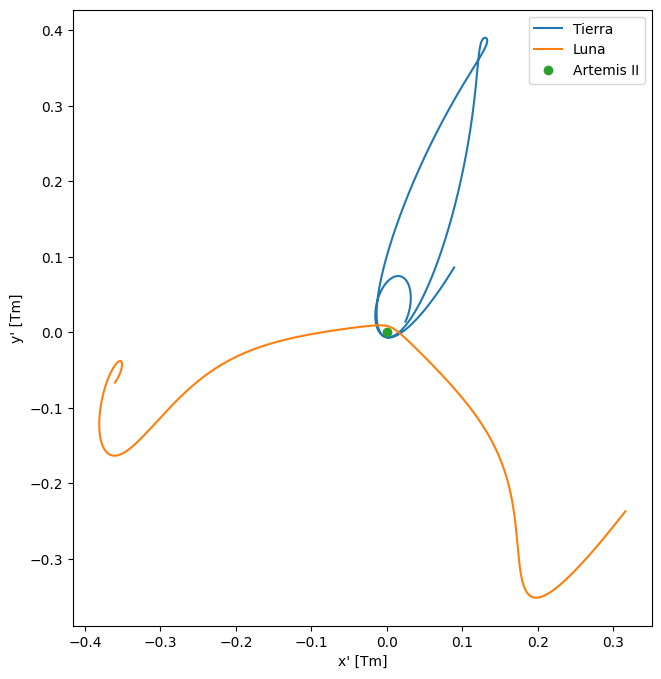

In [80]:

r_moon = usar[:, 0:3, 2]
r_earth = usar[:, 0:3, 1]

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(r_earth[:,0], r_earth[:,1], label="Tierra")
ax.plot(r_moon[:,0], r_moon[:,1], "-", label="Luna")
plt.plot(0,0,"o", label="Artemis II")
plt.legend()
plt.xlabel("x' [Tm]")
plt.ylabel("y' [Tm]")
ax.set_aspect("equal")
plt.show()

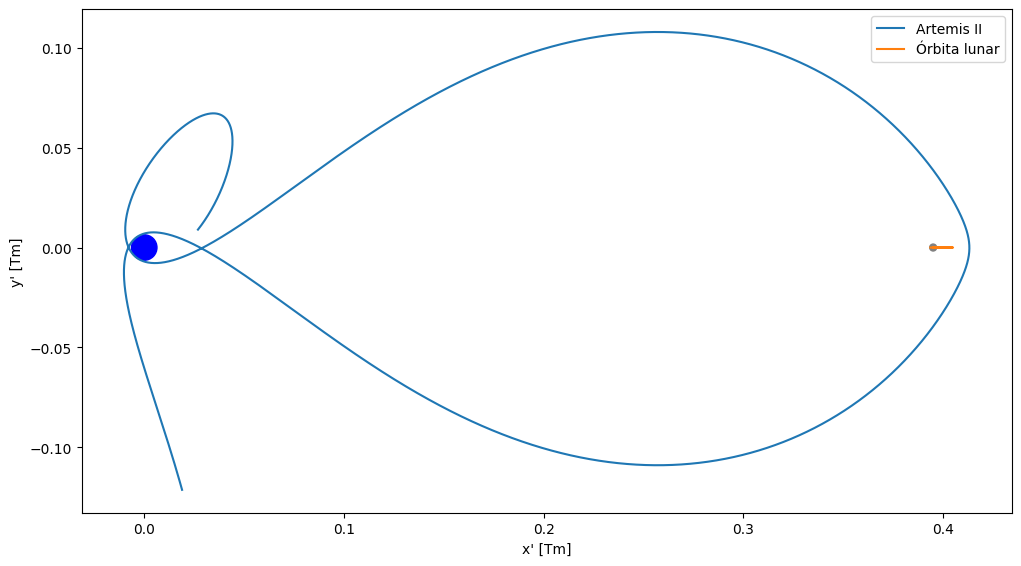

In [64]:
# Otra manera de hacer la trayectoria: graficar en un sistema de coordenadas con la tierra y la luna fijas
# mas que nada chatgpt


# positions (example: Artemis wrt Earth, Moon wrt Earth)
r_sc   = -usar[:, 0:3, 1]         
r_moon = usar[:, 0:3, 2] - usar[:, 0:3, 1]
r_earth = np.zeros_like(r_sc)             # Earth at origin

# --- build rotating frame (Earth–Moon axis fixed) ---
ex = r_moon / np.linalg.norm(r_moon, axis=1)[:, None]   # x' along Earth→Moon
ez = np.cross(r_moon, np.gradient(r_moon, axis=0))
ez /= np.linalg.norm(ez, axis=1)[:, None]               # ẑ ~ orbital normal
ey = np.cross(ez, ex)                                   # ŷ completes frame

# rotation matrices (N,3,3)
R = np.stack([ex, ey, ez], axis=1)

# rotate vectors into this frame
def rotate(v):
    return np.einsum("nij,nj->ni", R, v)

sc_rot   = rotate(r_sc)
moon_rot = rotate(r_moon)

# --- plot in rotating frame ---
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(sc_rot[:,0], sc_rot[:,1], label="Artemis II")
ax.plot(moon_rot[:,0], moon_rot[:,1], "-", label="Órbita lunar")

# Earth & Moon as circles
R_earth = 6371 * DISTANCE_FACTOR
R_moon  = 1737 * DISTANCE_FACTOR

earth = plt.Circle((0,0), R_earth, color="blue")
moon  = plt.Circle((moon_rot[-1,0], moon_rot[-1,1]), R_moon, color="gray")

ax.add_patch(earth)
ax.add_patch(moon)
plt.xlabel("x' [Tm]")
plt.ylabel("y' [Tm]")
ax.set_aspect("equal")
ax.legend()
plt.show()


(3, 3) (53903, 3)


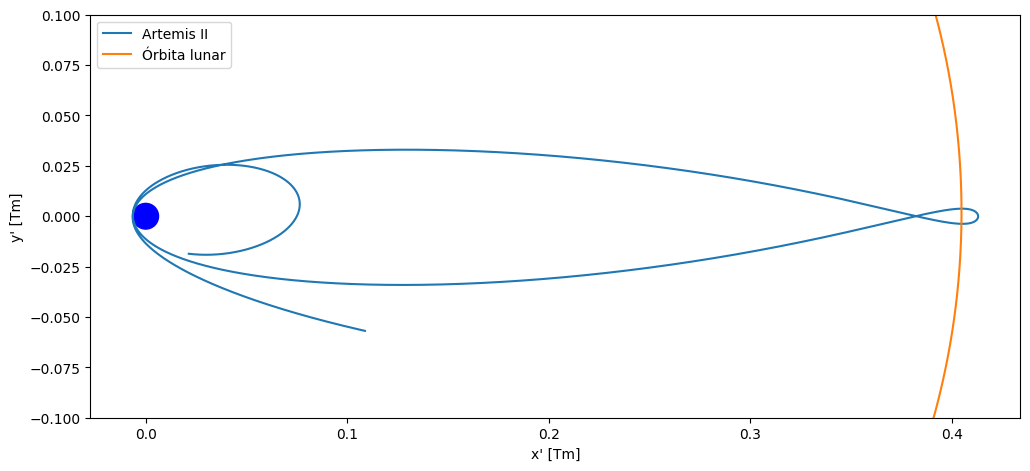

In [74]:
# Con la el perilunio en la derecha

luna_periapsis = np.argmin(np.linalg.norm(usar[:,0:3,2],axis=1))

# positions (example: Artemis wrt Earth, Moon wrt Earth)
r_sc   = -usar[:, 0:3, 1]         
r_moon = usar[:, 0:3, 2] - usar[:, 0:3, 1]
r_earth = np.zeros_like(r_sc)             # Earth at origin

# --- build rotating frame (Earth–Moon axis fixed) ---
ex = r_moon / np.linalg.norm(r_moon, axis=1)[:, None]   # x' along Earth→Moon
ez = np.cross(r_moon, np.gradient(r_moon, axis=0))
ez /= np.linalg.norm(ez, axis=1)[:, None]               # ẑ ~ orbital normal
ey = np.cross(ez, ex)                                   # ŷ completes frame

# usar solo la matriz de rotacion en el periapsis
R = np.stack([ex, ey, ez], axis=1)[luna_periapsis]

print(R.shape, r_sc.shape)

sc_rot   = (R @ r_sc.T).T
moon_rot = (R @ r_moon.T).T

# --- plot in rotating frame ---
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(sc_rot[:,0], sc_rot[:,1], label="Artemis II")
ax.plot(moon_rot[:,0], moon_rot[:,1], "-", label="Órbita lunar")

# Earth & Moon as circles
R_earth = 6371 * DISTANCE_FACTOR
R_moon  = 1737 * DISTANCE_FACTOR

earth = plt.Circle((0,0), R_earth, color="blue")
moon  = plt.Circle((moon_rot[-1,0], moon_rot[-1,1]), R_moon, color="gray")

ax.add_patch(earth)
ax.add_patch(moon)
plt.xlabel("x' [Tm]")
plt.ylabel("y' [Tm]")
ax.set_aspect("equal")
plt.ylim(-0.1,0.1)
ax.legend()
plt.show()


In [ ]:
# Lo más importante de todo :)
from matplotlib.patches import Arc
fig,ax=plt.subplots()
list(map(ax.add_patch, [plt.Circle((0,0),1,fill=False,linewidth=2)
,plt.Circle((-.3,.3),.1,color='black')
,plt.Circle((.3,.3),.1,color='black')
,Arc((0,0),1.2,1,theta1=200,theta2=340,linewidth=2)]))
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')
plt.axis('off')
plt.show()